1. Imports & Data Loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('advertising.csv')

# Drop index column if present (e.g., 'Unnamed: 0')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


2. Exploratory Data Analysis

In [9]:
print("Columns:",df.columns)
print("Shape:",df.shape)
print(df.head(2))

Columns: Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')
Shape: (200, 4)
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4


Cleaned Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Missing Values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


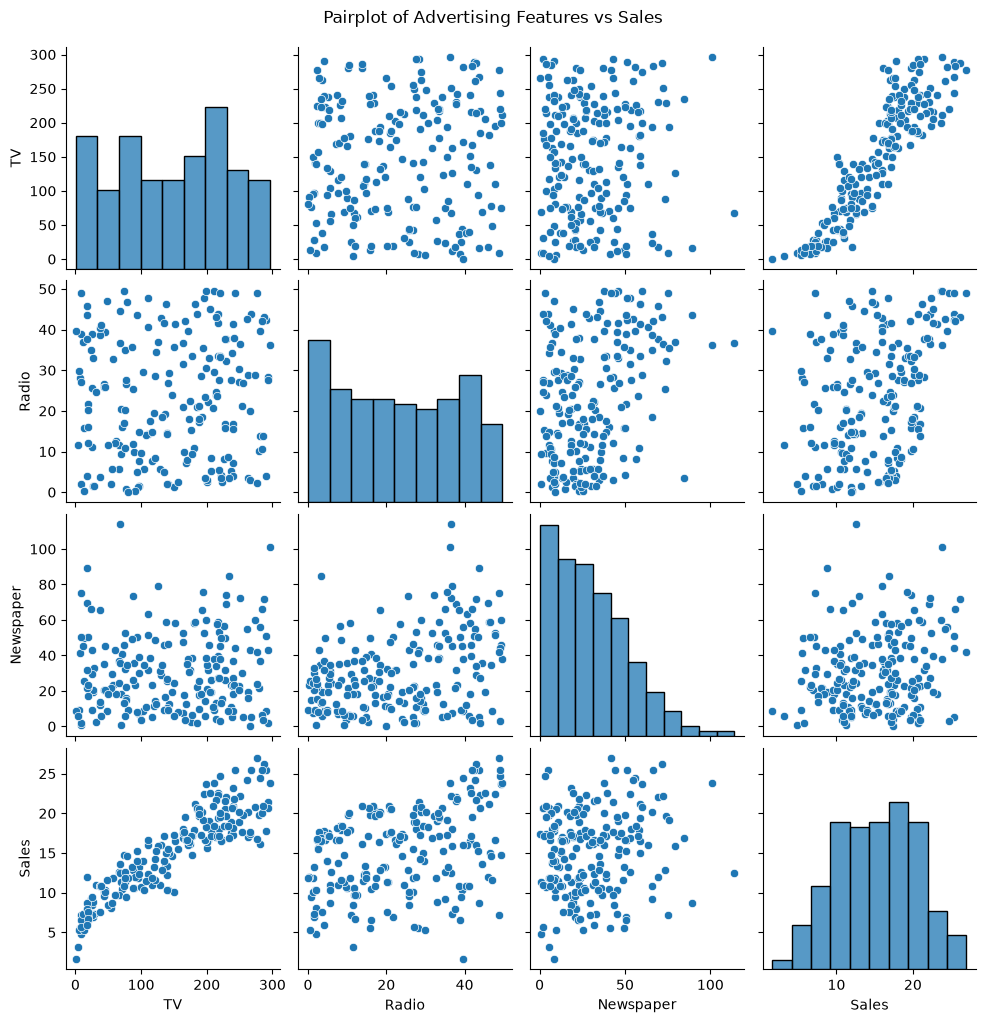

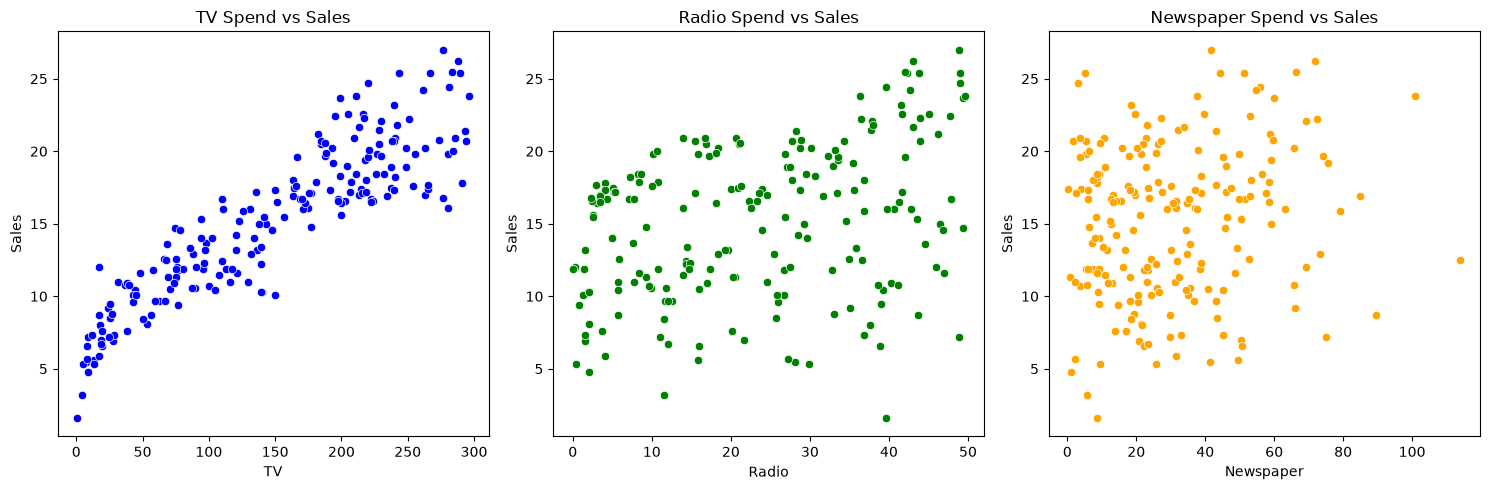

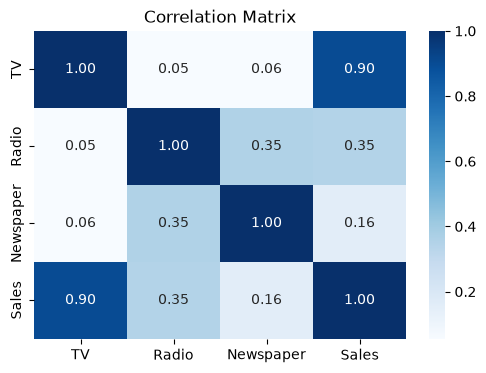

In [10]:
# Strip any extra spaces from column names to prevent key errors
df.columns = df.columns.str.strip()

# Print actual column names to double-check
print("Cleaned Columns:", df.columns.tolist())

# Check missing values and summary statistics
print("\nMissing Values:\n", df.isnull().sum())

# Pairplot across all features
sns.pairplot(df)
plt.suptitle('Pairplot of Advertising Features vs Sales', y=1.02)
plt.show()

# Individual Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0], color='blue')
sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1], color='green')
sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2], color='orange')

axes[0].set_title('TV Spend vs Sales')
axes[1].set_title('Radio Spend vs Sales')
axes[2].set_title('Newspaper Spend vs Sales')
plt.tight_layout()
plt.show()

# Correlation Heatmap (only on numeric columns)
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

3. Train/Test Split

In [11]:
# Feature and Target separation
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Train set size: 160 samples
Test set size: 40 samples


4. Train Models

In [12]:
# Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Additional Model: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [13]:
# Evaluate Linear Regression
print("--- Linear Regression ---")
print("MAE :", mean_absolute_error(y_test, lr_preds))
print("MSE :", mean_squared_error(y_test, lr_preds))
print("R2  :", r2_score(y_test, lr_preds))

print("\n--- Random Forest ---")
print("MAE :", mean_absolute_error(y_test, rf_preds))
print("MSE :", mean_squared_error(y_test, rf_preds))
print("R2  :", r2_score(y_test, rf_preds))

--- Linear Regression ---
MAE : 1.2748262109549338
MSE : 2.9077569102710896
R2  : 0.9059011844150826

--- Random Forest ---
MAE : 0.9179999999999993
MSE : 1.4374328500000009
R2  : 0.9534827934927883


5. Model Evaluation

In [14]:
def evaluate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== {model_name} ===")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

evaluate_metrics(y_test, lr_preds, "Linear Regression")
evaluate_metrics(y_test, rf_preds, "Random Forest Regressor")

=== Linear Regression ===
MAE:  1.2748
RMSE: 1.7052
R²:   0.9059

=== Random Forest Regressor ===
MAE:  0.9180
RMSE: 1.1989
R²:   0.9535



6. Residual Plot & Channel Impact Analysis

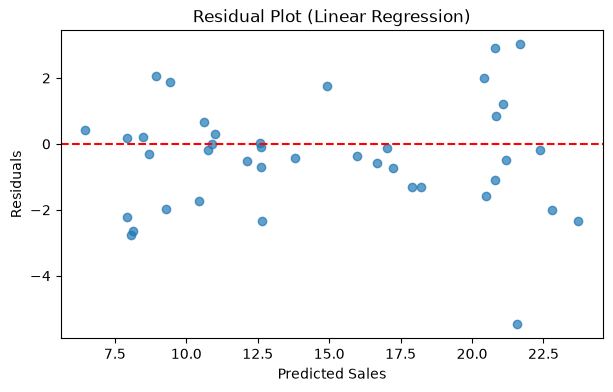

Linear Regression Coefficients:


,Channel,Coefficient
1,Radio,0.100945
0,TV,0.054509
2,Newspaper,0.004337


In [19]:
# Residual Plot for Best Model (Linear Regression)
residuals = y_test - lr_preds

plt.figure(figsize=(7, 4))
plt.scatter(lr_preds, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot (Linear Regression)')
plt.show()

# Coefficients / Channel Impact Interpretation
coefficients = pd.DataFrame({
    'Channel': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Linear Regression Coefficients:")
display(coefficients)

7. Random Forest Features Importance

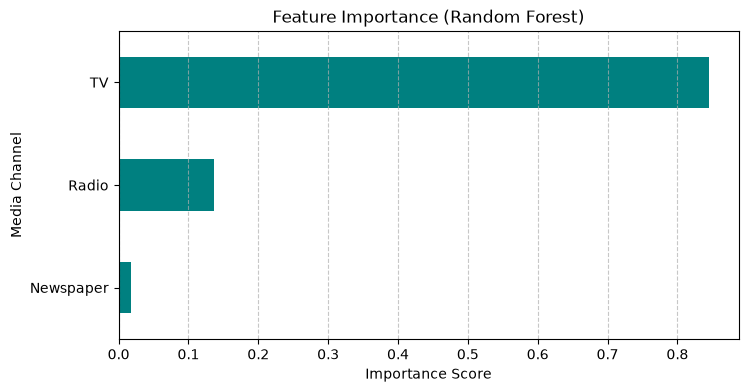

In [16]:
# Feature Importance for Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Media Channel')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

8. Actual vs. Predicted Sales Comparison

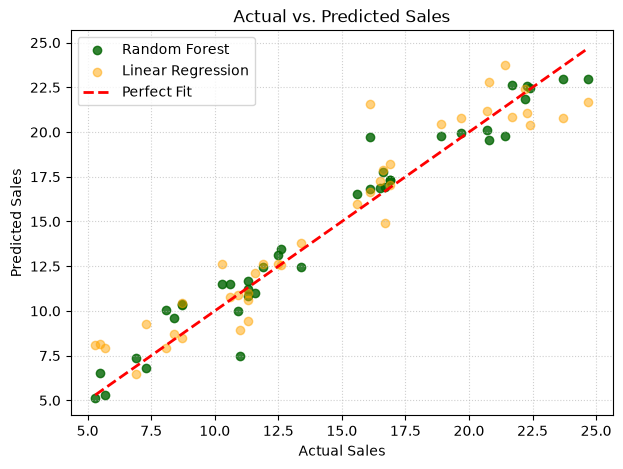

In [17]:
# Actual vs Predicted Sales Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_preds, alpha=0.8, color='darkgreen', label='Random Forest')
plt.scatter(y_test, lr_preds, alpha=0.5, color='orange', label='Linear Regression')

# Perfect prediction diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs. Predicted Sales')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

9. Sales Prediction Function

In [18]:
def predict_sales(tv_spend, radio_spend, newspaper_spend):
    """
    Predicts sales based on custom advertising budgets using the trained Random Forest model.
    """
    input_data = pd.DataFrame([[tv_spend, radio_spend, newspaper_spend]], 
                              columns=['TV', 'Radio', 'Newspaper'])
    predicted_sales = rf.predict(input_data)[0]
    
    print(f"--- Budget Scenario ---")
    print(f"TV Spend       : ${tv_spend:.2f}")
    print(f"Radio Spend    : ${radio_spend:.2f}")
    print(f"Newspaper Spend: ${newspaper_spend:.2f}")
    print(f"-----------------------")
    print(f"Estimated Sales: {predicted_sales:.2f} units\n")

# Example usage:
predict_sales(tv_spend=200.0, radio_spend=40.0, newspaper_spend=10.0)

--- Budget Scenario ---
TV Spend       : $200.00
Radio Spend    : $40.00
Newspaper Spend: $10.00
-----------------------
Estimated Sales: 21.09 units

